## Part 1: Dataset Loading

In [1]:
pip install ucimlrepo

In [2]:
# Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

# metadata
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata)

# variable information
print(diabetes_130_us_hospitals_for_years_1999_2008.variables)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

In [4]:
# Combine in a df and have a look
df = pd.concat([X, y], axis=1)
print(f"Shape: {df.shape}")
df.head()

Shape: (101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Part 2: Preprocessing

In [5]:
# Drop those extreme missingness cols
drop_cols = ['weight', 'max_glu_serum', 'A1Cresult', 'payer_code']
df_clean = df.drop(columns=drop_cols)
df_clean.shape

(101766, 44)

In [6]:
# Create binary target: 1 = readmitted within 30 days, 0 = not
df_clean['readmit_30'] = (df_clean['readmitted'] == '<30').astype(int)
print("Binary target distribution:")
print(df_clean['readmit_30'].value_counts())
print(f"\nPositive class rate: {df_clean['readmit_30'].mean():.2%}")

Binary target distribution:
readmit_30
0    90409
1    11357
Name: count, dtype: int64

Positive class rate: 11.16%


In [7]:
# Drop columns that are not useful for modeling (further)
drop_cols = [
    'readmitted',          # replaced by readmit_30
    'encounter_id',        # ID
    'patient_nbr',         # ID
    'medical_specialty',   # ~49% missing
]
df_model = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
print(f"Shape after dropping IDs & high-missing: {df_model.shape}")

Shape after dropping IDs & high-missing: (101766, 43)


In [8]:
# Handle remaining missing values
print("Missing values before handling:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# Fill race with mode, drop rows with missing diag codes
df_model['race'] = df_model['race'].fillna(df_model['race'].mode()[0])
df_model = df_model.dropna(subset=['diag_1', 'diag_2', 'diag_3'])

print(f"\nShape after handling missing: {df_model.shape}")
print(f"Remaining nulls: {df_model.isnull().sum().sum()}")

Missing values before handling:
race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64

Shape after handling missing: (100244, 43)
Remaining nulls: 0


In [9]:
# admission_type_id, discharge_disposition_id, admission_source_id
# are categorical but encoded as integers — convert them
cat_id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in cat_id_cols:
    df_model[col] = df_model[col].astype(str)

# Identify categorical vs numeric columns
target = 'readmit_30'
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include='number').columns.tolist()
num_cols.remove(target)

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")

Categorical features (34): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Numeric features (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [10]:
# Encode categorical features into binary
# Save 'race' column BEFORE encoding — need it for the fairness audit
race_column = df_model['race'].copy()

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape after encoding: (100244, 2366)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmit_30,race_Asian,...,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes
1,3,59,0,18,0,0,0,9,0,False,...,True,True,False,False,False,False,False,False,False,True
2,2,11,5,13,2,0,1,6,0,False,...,False,True,False,False,False,False,False,False,True,True
3,2,44,1,16,0,0,0,7,0,False,...,True,True,False,False,False,False,False,False,False,True
4,1,51,0,8,0,0,0,5,0,False,...,False,True,False,False,False,False,False,False,False,True
5,3,31,6,16,0,0,0,9,0,False,...,False,True,False,False,False,False,False,False,True,True


## Part 3: Exploratory Data Analysis

In [11]:
# Set styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [12]:
# Check data type and non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [13]:
# Check missing values
missing = df.isnull().sum()
missing

,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
payer_code,40256
medical_specialty,49949


In [14]:
# Worst cols with null
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percent', ascending=False)
missing_df

,count,percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [15]:
# Summary stats for numeric cols
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


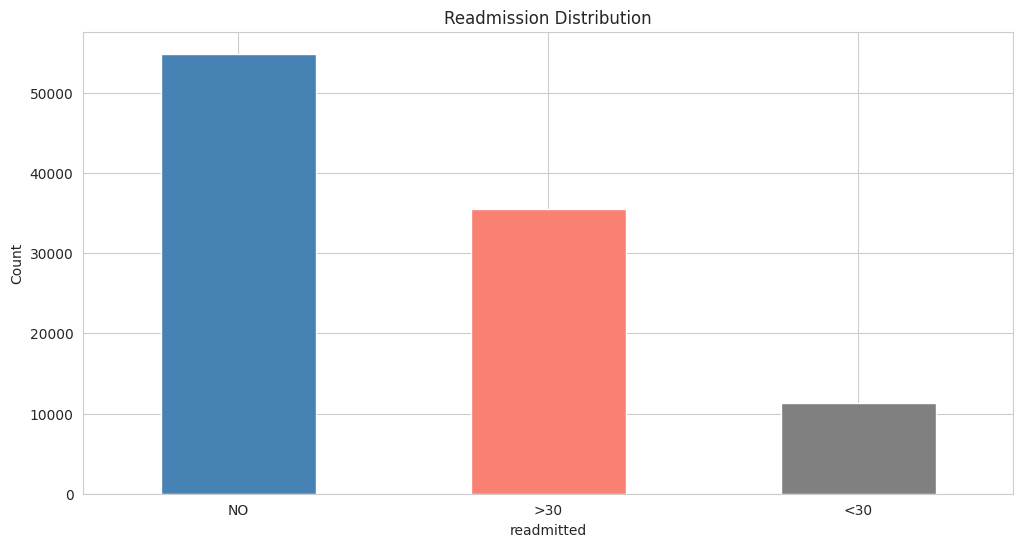

In [16]:
# Targets distribution
print(df['readmitted'].value_counts())
df['readmitted'].value_counts().plot(kind='bar', color=['steelblue', 'salmon', 'gray'])
plt.title('Readmission Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Numeric columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmit_30']


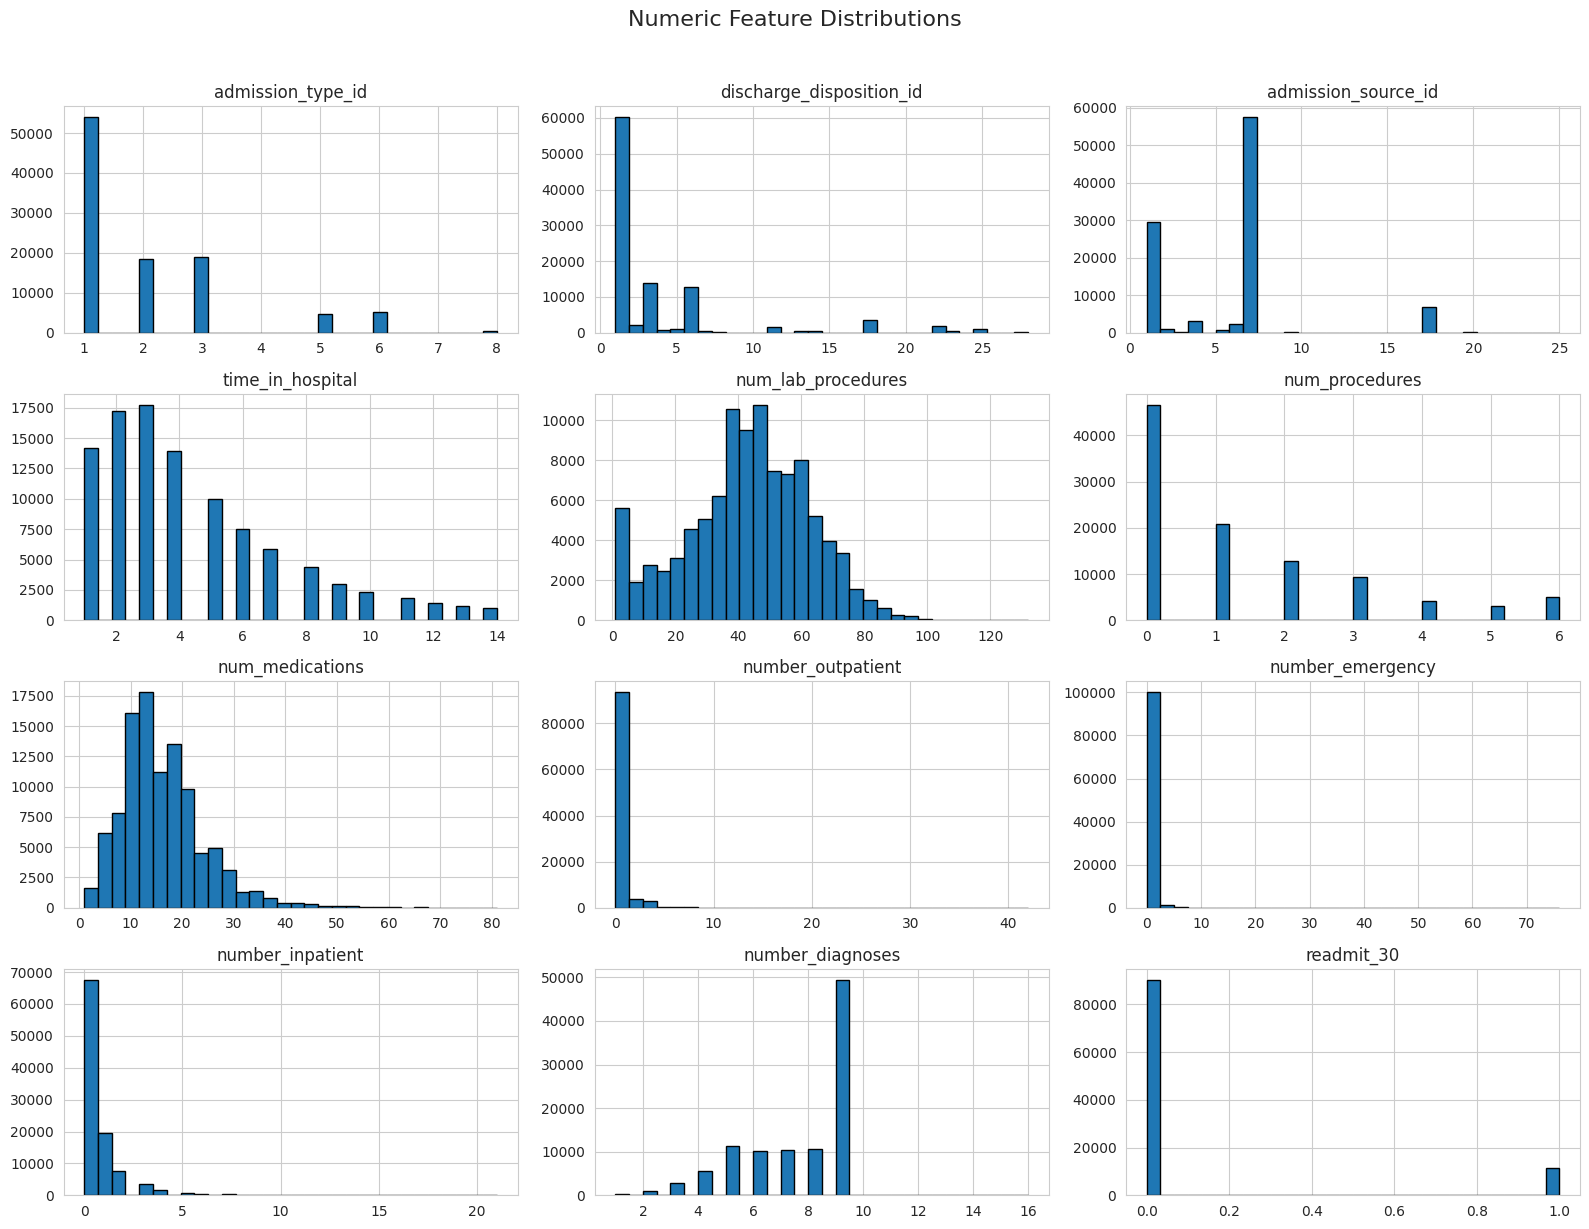

In [17]:
# Numeric features distributions
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", num_cols)

df_clean[num_cols].hist(bins=30, figsize=(16, 12), edgecolor='black')
plt.suptitle('Numeric Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
"""
1. number_outpatient, number_emergency, number_inpatient are heavily right-skewed. Most patients have 0 prior visits, with a long tail of frequent visitors
2. num_medications and num_lab_procedures are roughly bell-shaped, but still skewed
3. time_in_hospital is right-skewed — most stays are 1–4 days
PS: admission_type_id, discharge_disposition_id, admission_source_id are categorical encoded as integers
"""

'\n1. number_outpatient, number_emergency, number_inpatient are heavily right-skewed. Most patients have 0 prior visits, with a long tail of frequent visitors\n2. num_medications and num_lab_procedures are roughly bell-shaped, but still skewed\n3. time_in_hospital is right-skewed — most stays are 1–4 days\nPS: admission_type_id, discharge_disposition_id, admission_source_id are categorical encoded as integers\n'

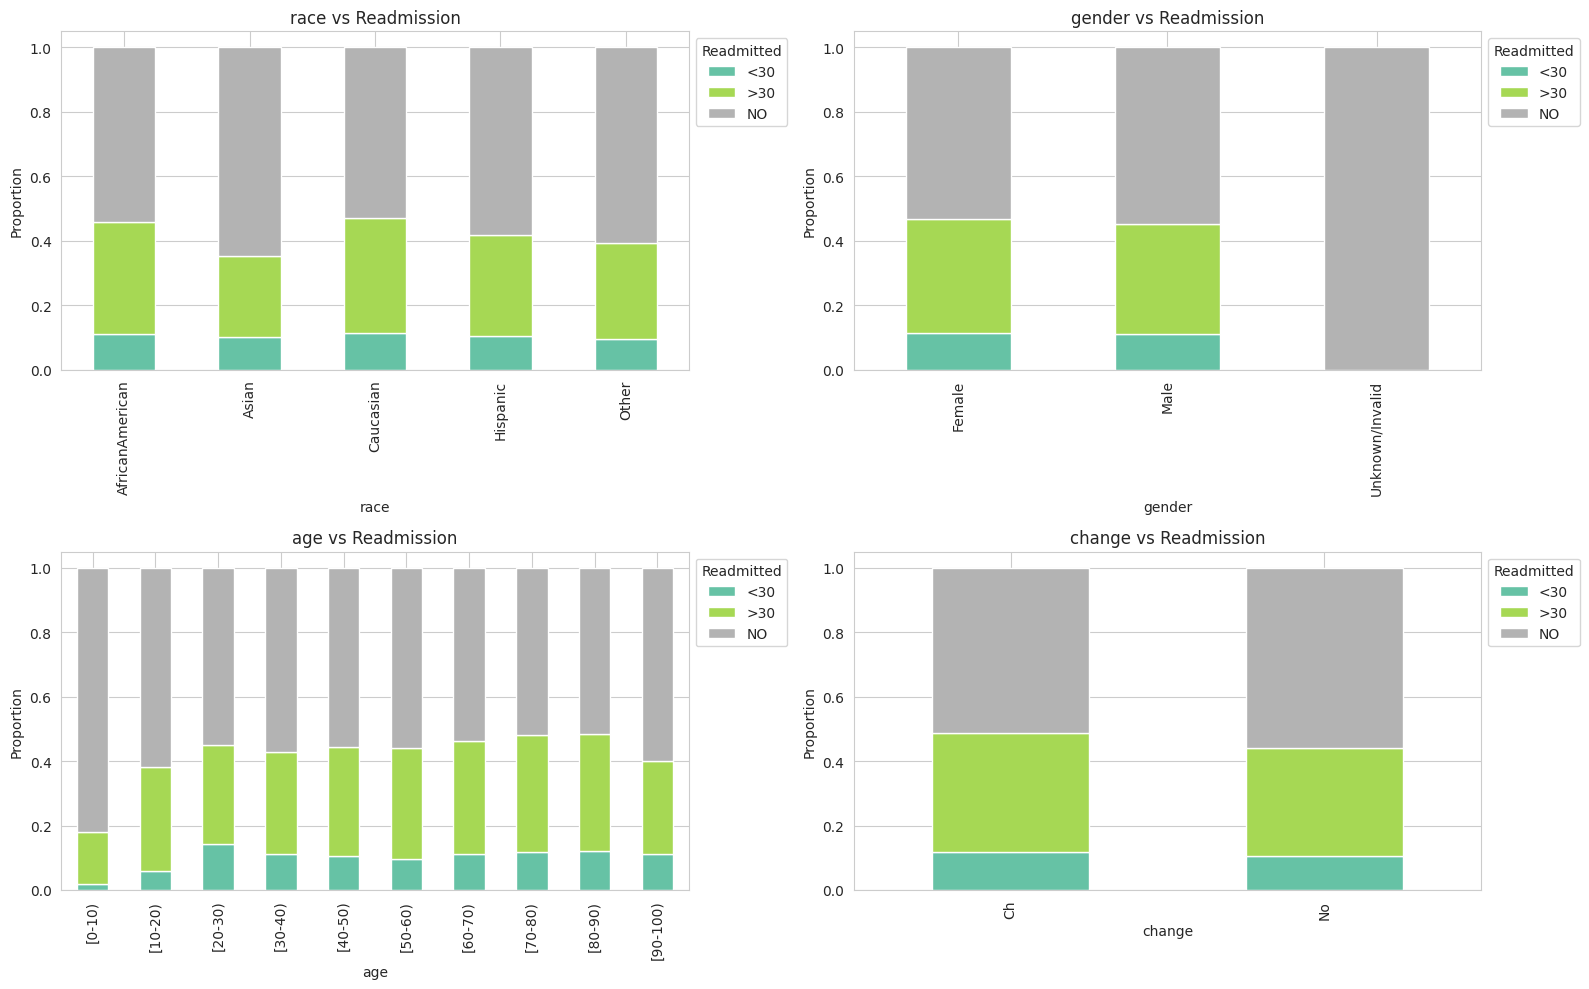

In [19]:
# Key Categorical features vs readmission
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, col in zip(axes.flatten(), ['race', 'gender', 'age', 'change']):
    pd.crosstab(df_clean[col], df_clean['readmitted'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, colormap='Set2'
    )
    ax.set_title(f'{col} vs Readmission')
    ax.set_ylabel('Proportion')
    ax.legend(title='Readmitted', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [20]:
"""
1. Race & gender show very similar readmission proportions across groups — not strong predictors on their own
2. Age has more to say. Younger patients (0-30) have lower readmission rates, while middle-aged and older patients (40-90) have higher and more consistent readmission. The [30-40) group has a notable spike in <30 day readmission
"""

'\n1. Race & gender show very similar readmission proportions across groups — not strong predictors on their own\n2. Age has more to say. Younger patients (0-30) have lower readmission rates, while middle-aged and older patients (40-90) have higher and more consistent readmission. The [30-40) group has a notable spike in <30 day readmission\n'

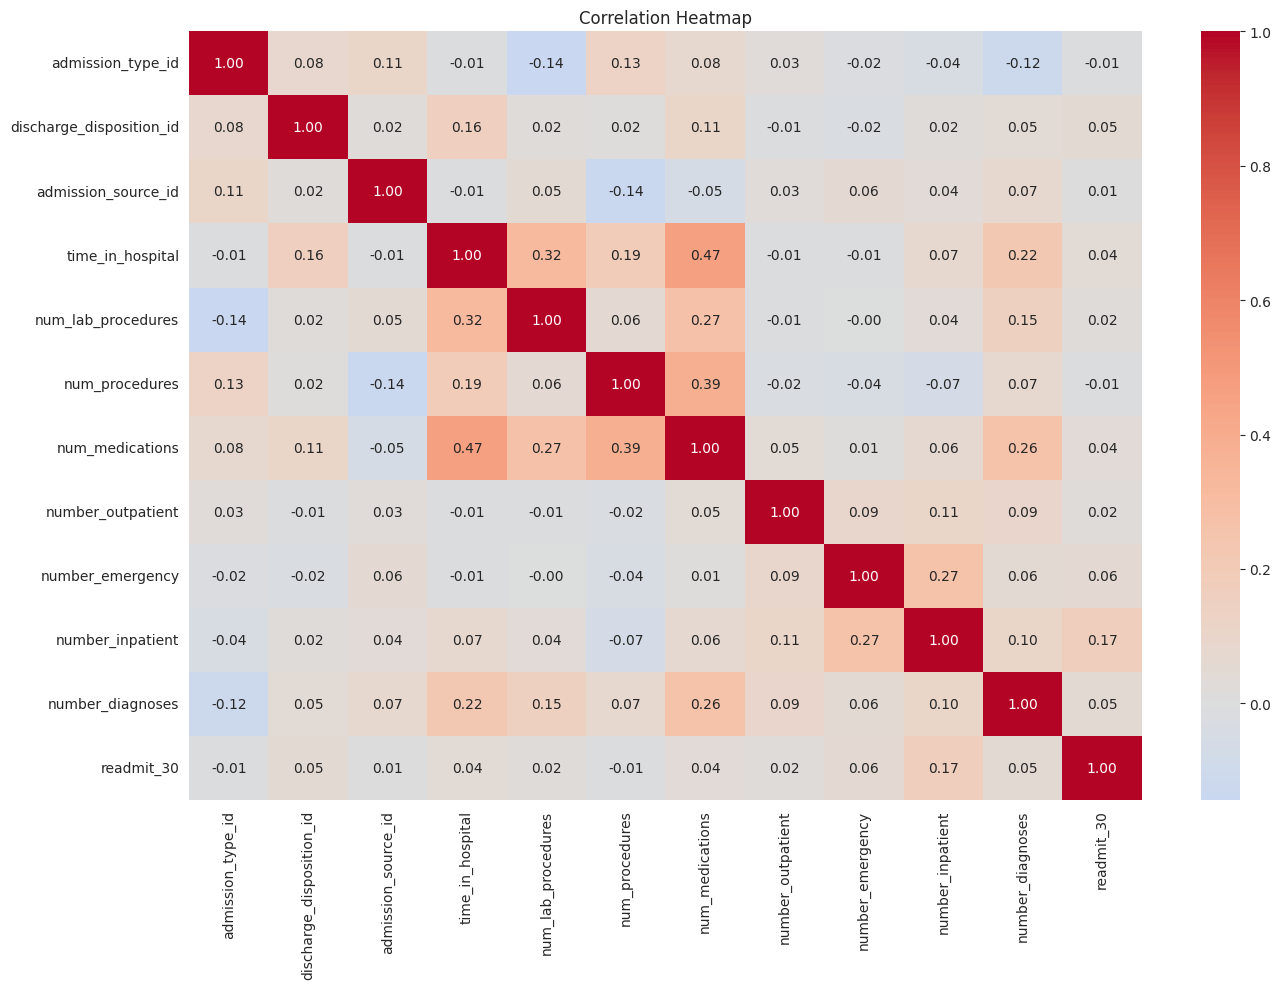

In [21]:
# Correlation heatmap for numeric features
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [22]:
"""
No alarming multicollinearity — nothing above 0.5
"""

'\nNo alarming multicollinearity — nothing above 0.5\n'

/tmp/ipykernel_21219/2282455488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='time_in_hospital', data=df_clean, ax=axes[0], palette='Set2')
/tmp/ipykernel_21219/2282455488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='num_medications', data=df_clean, ax=axes[1], palette='Set2')


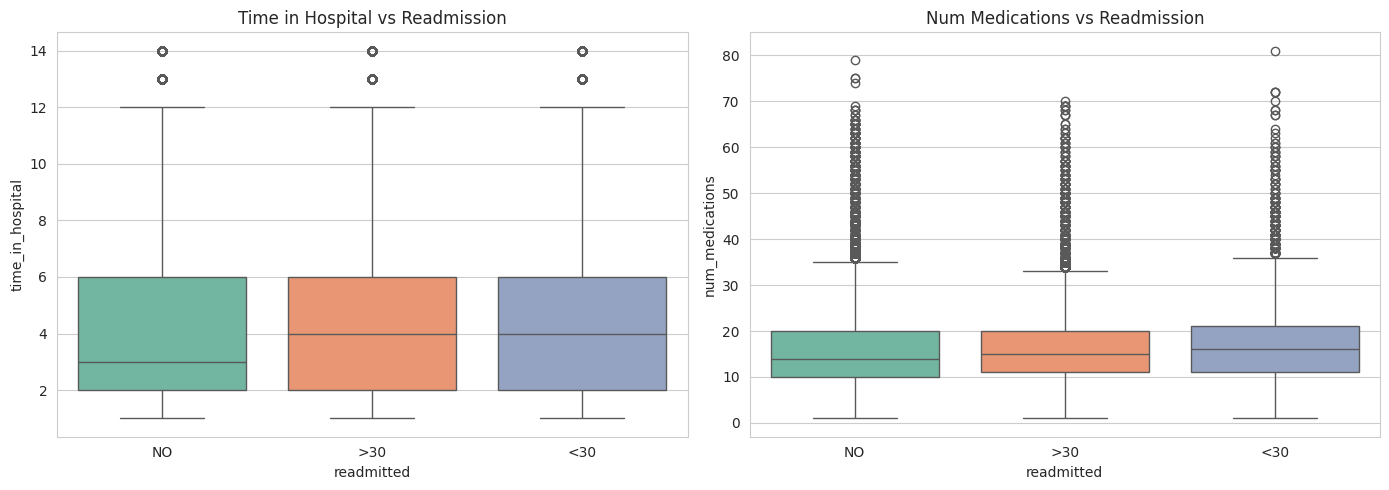

In [23]:
# Time in hospital vs readmission (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='readmitted', y='time_in_hospital', data=df_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Time in Hospital vs Readmission')

sns.boxplot(x='readmitted', y='num_medications', data=df_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Num Medications vs Readmission')

plt.tight_layout()
plt.show()

In [24]:
"""
The medians and IQRs are nearly identical. These won't be strong standalone predictors, though they may still contribute in a model combined with other features.

`num_medications` has lots of outliers. Actually this exploration may be useless
"""

"\nThe medians and IQRs are nearly identical. These won't be strong standalone predictors, though they may still contribute in a model combined with other features.\n\n`num_medications` has lots of outliers. Actually this exploration may be useless\n"

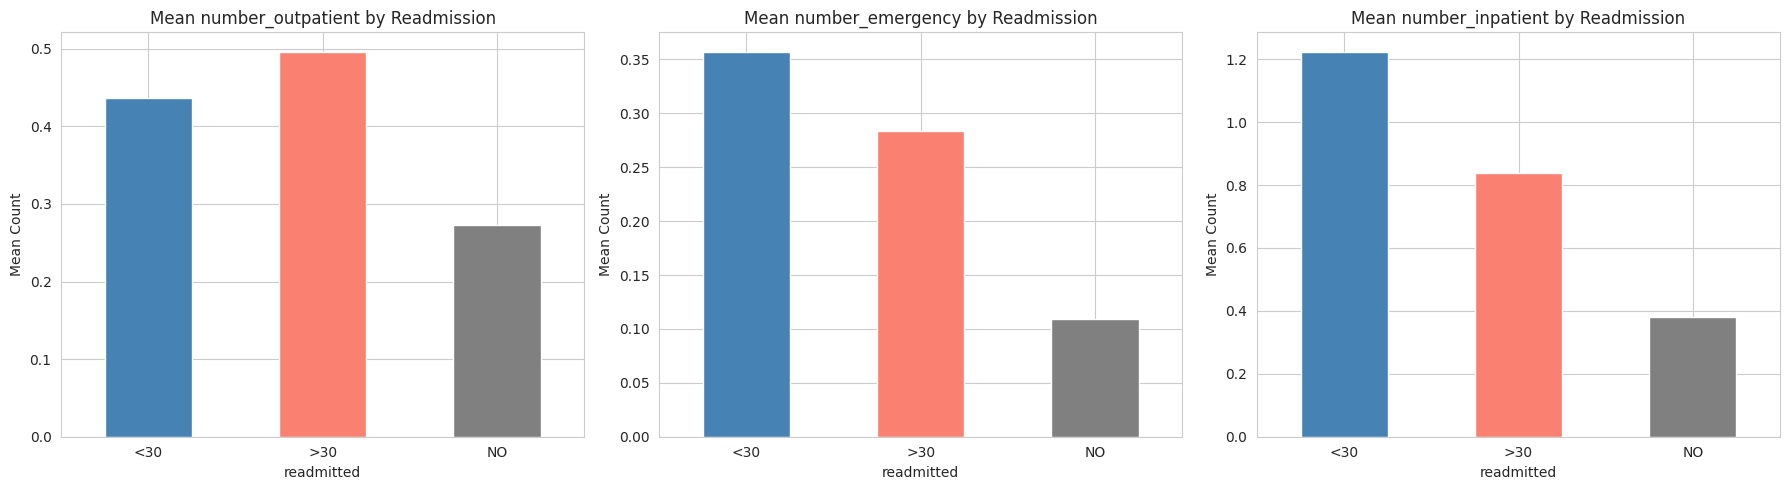

In [25]:
# Prior visits vs readmission — are frequent visitors readmitted more?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['number_outpatient', 'number_emergency', 'number_inpatient']):
    df_clean.groupby('readmitted')[col].mean().plot(kind='bar', ax=ax, color=['steelblue', 'salmon', 'gray'])
    ax.set_title(f'Mean {col} by Readmission')
    ax.set_ylabel('Mean Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [26]:
"""
Patients readmitted within <30 days have significantly higher prior emergency and inpatient visit counts compared to "NO" readmission.
This is a clear signal — patients who frequently use the hospital are more likely to be readmitted early.

No tests on this, just seeking for possible research questions.
"""

'\nPatients readmitted within <30 days have significantly higher prior emergency and inpatient visit counts compared to "NO" readmission.\nThis is a clear signal — patients who frequently use the hospital are more likely to be readmitted early.\n\nNo tests on this, just seeking for possible research questions.\n'


Performing Unsupervised Clustering (Clinical Phenotypes)


/tmp/ipykernel_21219/609005290.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clinical_cluster', y='time_in_hospital', data=df_model, ax=axes[0], palette='viridis')
/tmp/ipykernel_21219/609005290.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clinical_cluster', y='num_medications', data=df_model, ax=axes[1], palette='viridis')
/tmp/ipykernel_21219/609005290.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='clinical_cluster', y='num_lab_procedures', data=df_model, ax=axes[2], palette='viridis')


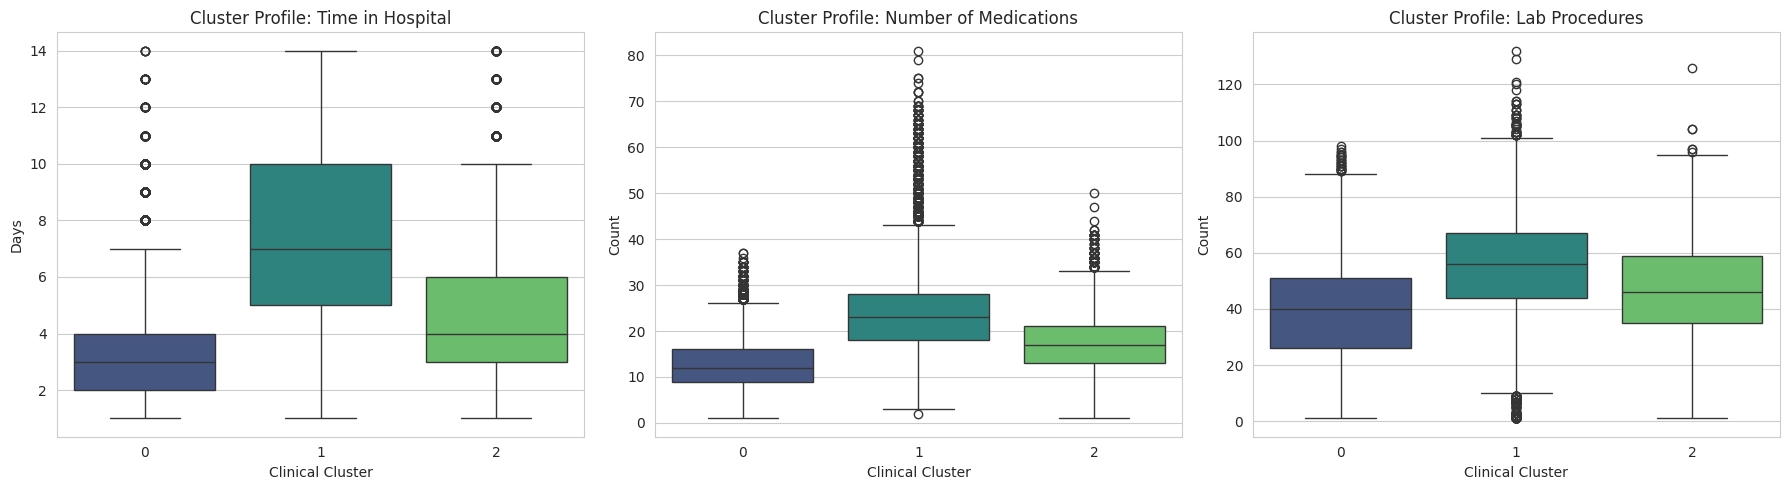

In [27]:
# CLUSTERING
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("\nPerforming Unsupervised Clustering (Clinical Phenotypes)")
cluster_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                    'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']

# Use a data copy for clustering to prevent data leakage
X_cluster = df_model[cluster_features].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Execute K-Means (setting k=3 to identify three distinct clinical profiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['clinical_cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Visualizing Cluster Profiles via Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Profile 1: Duration of stay
sns.boxplot(x='clinical_cluster', y='time_in_hospital', data=df_model, ax=axes[0], palette='viridis')
axes[0].set_title('Cluster Profile: Time in Hospital')
axes[0].set_xlabel('Clinical Cluster')
axes[0].set_ylabel('Days')

# Profile 2: Medication count
sns.boxplot(x='clinical_cluster', y='num_medications', data=df_model, ax=axes[1], palette='viridis')
axes[1].set_title('Cluster Profile: Number of Medications')
axes[1].set_xlabel('Clinical Cluster')
axes[1].set_ylabel('Count')

# Profile 3: Intensity of diagnostics
sns.boxplot(x='clinical_cluster', y='num_lab_procedures', data=df_model, ax=axes[2], palette='viridis')
axes[2].set_title('Cluster Profile: Lab Procedures')
axes[2].set_xlabel('Clinical Cluster')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Drop the cluster labels after plotting to ensure classification model remains unchanged
df_model = df_model.drop(columns=['clinical_cluster'])

In [28]:
df_export = df_encoded.copy()
df_export['original_race'] = race_column.values
df_export.to_csv('processed_diabetes_data.csv', index=False)
print("Step 1 Complete: Processed data saved to 'processed_diabetes_data.csv'")

Step 1 Complete: Processed data saved to 'processed_diabetes_data.csv'
